In [ ]:
!pip install -q kagglehub

In [ ]:
import kagglehub

kagglehub.login()

Kaggle credentials set.
Kaggle credentials successfully validated.


In [ ]:
dataset_path = kagglehub.dataset_download(
    "dramakc/raj-lee-images"
)

print("Dataset downloaded to:")
print(dataset_path)

100%|██████████| 5.32M/5.32M [00:00<00:00, 56.1MB/s]

Extracting files...
Dataset downloaded to:
/root/.cache/kagglehub/datasets/dramakc/raj-lee-images/versions/1


In [ ]:
import os

print(os.listdir(dataset_path))

['Class 1-samples', 'leeshal-samples']


In [ ]:
import zipfile
import os

for file in os.listdir(dataset_path):

    if file.endswith(".zip"):

        zip_path = os.path.join(dataset_path, file)

        print("Extracting:", file)

        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(dataset_path)

print("Extraction completed!")

Extraction completed!


In [ ]:
!find "$dataset_path" -maxdepth 3 -type d

/root/.cache/kagglehub/datasets/dramakc/raj-lee-images/versions/1
/root/.cache/kagglehub/datasets/dramakc/raj-lee-images/versions/1/Class 1-samples
/root/.cache/kagglehub/datasets/dramakc/raj-lee-images/versions/1/leeshal-samples


In [ ]:
import os

dataset_path = "/root/.cache/kagglehub/datasets/dramakc/raj-lee-images/versions/1"

class_a_source = os.path.join(dataset_path, "Class 1-samples")
class_b_source = os.path.join(dataset_path, "leeshal-samples")

print("Class A folder:", class_a_source)
print("Class B folder:", class_b_source)

Class A folder: /root/.cache/kagglehub/datasets/dramakc/raj-lee-images/versions/1/Class 1-samples
Class B folder: /root/.cache/kagglehub/datasets/dramakc/raj-lee-images/versions/1/leeshal-samples


In [ ]:
def count_images(folder):
    extensions = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

    count = 0

    for root, dirs, files in os.walk(folder):
        for file in files:
            if file.lower().endswith(extensions):
                count += 1

    return count


print("Class A images:", count_images(class_a_source))
print("Class B images:", count_images(class_b_source))

Class A images: 165
Class B images: 269


In [ ]:
import os
import shutil
import random

# Original folders
class_a_source = os.path.join(dataset_path, "Class 1-samples")
class_b_source = os.path.join(dataset_path, "leeshal-samples")

# New balanced dataset
new_dataset = "/content/cnn_dataset"

class_a = os.path.join(new_dataset, "Class_A")
class_b = os.path.join(new_dataset, "Class_B")

os.makedirs(class_a, exist_ok=True)
os.makedirs(class_b, exist_ok=True)

# Get image files
extensions = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

class_a_images = [
    os.path.join(class_a_source, f)
    for f in os.listdir(class_a_source)
    if f.lower().endswith(extensions)
]

class_b_images = [
    os.path.join(class_b_source, f)
    for f in os.listdir(class_b_source)
    if f.lower().endswith(extensions)
]

# Randomly select 150 from each
random.seed(42)

class_a_selected = random.sample(class_a_images, 150)
class_b_selected = random.sample(class_b_images, 150)

# Copy Class A
for i, file_path in enumerate(class_a_selected):
    extension = os.path.splitext(file_path)[1]
    destination = os.path.join(class_a, f"classA_{i}{extension}")
    shutil.copy2(file_path, destination)

# Copy Class B
for i, file_path in enumerate(class_b_selected):
    extension = os.path.splitext(file_path)[1]
    destination = os.path.join(class_b, f"classB_{i}{extension}")
    shutil.copy2(file_path, destination)

print("Balanced dataset created!")
print("Class A:", len(os.listdir(class_a)))
print("Class B:", len(os.listdir(class_b)))
print("Total:", len(os.listdir(class_a)) + len(os.listdir(class_b)))

Balanced dataset created!
Class A: 150
Class B: 150
Total: 300


In [ ]:
print(os.listdir(new_dataset))

['Class_B', 'Class_A']


In [ ]:
print("Class A:", len(os.listdir(class_a)))
print("Class B:", len(os.listdir(class_b)))
print("Total:", len(os.listdir(class_a)) + len(os.listdir(class_b)))

Class A: 150
Class B: 150
Total: 300


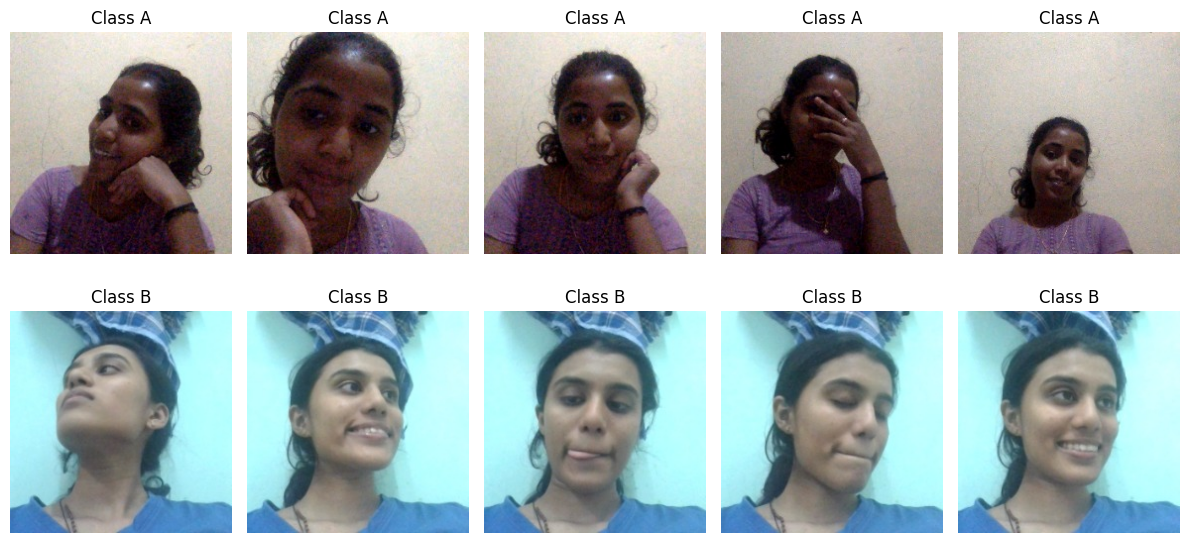

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import os

plt.figure(figsize=(12, 6))

# Show 5 Class A images
for i, file in enumerate(os.listdir(class_a)[:5]):
    img = Image.open(os.path.join(class_a, file))

    plt.subplot(2, 5, i + 1)
    plt.imshow(img)
    plt.title("Class A")
    plt.axis("off")

# Show 5 Class B images
for i, file in enumerate(os.listdir(class_b)[:5]):
    img = Image.open(os.path.join(class_b, file))

    plt.subplot(2, 5, i + 6)
    plt.imshow(img)
    plt.title("Class B")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import tensorflow as tf

IMG_SIZE = (180, 180)
BATCH_SIZE = 16
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    new_dataset,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    new_dataset,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 300 files belonging to 2 classes.
Using 240 files for training.
Found 300 files belonging to 2 classes.
Using 60 files for validation.


In [ ]:
print(train_ds.class_names)

['Class_A', 'Class_B']


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(240).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)

In [ ]:
from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

In [ ]:
model = tf.keras.Sequential([

    # Data augmentation
    data_augmentation,

    # Normalize pixel values: 0-255 → 0-1
    layers.Rescaling(1./255),

    # Convolution Block 1
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D(),

    # Convolution Block 2
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D(),

    # Convolution Block 3
    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D(),

    # Convert feature maps into a single vector
    layers.Flatten(),

    # Fully connected layer
    layers.Dense(128, activation="relu"),

    # Reduce overfitting
    layers.Dropout(0.5),

    # Binary classification
    layers.Dense(1, activation="sigmoid")
])

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
EPOCHS = 5

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 10s 61ms/step - accuracy: 0.7000 - loss: 0.9646 - val_accuracy: 1.0000 - val_loss: 0.0379
Epoch 2/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 1.0000 - loss: 0.0118 - val_accuracy: 1.0000 - val_loss: 1.1206e-05
Epoch 3/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 1.0000 - loss: 5.6019e-04 - val_accuracy: 1.0000 - val_loss: 2.7009e-05
Epoch 4/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 1.0000 - loss: 1.8228e-05 - val_accuracy: 1.0000 - val_loss: 1.7602e-07
Epoch 5/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 1.0000 - loss: 1.6829e-05 - val_accuracy: 1.0000 - val_loss: 1.3679e-06


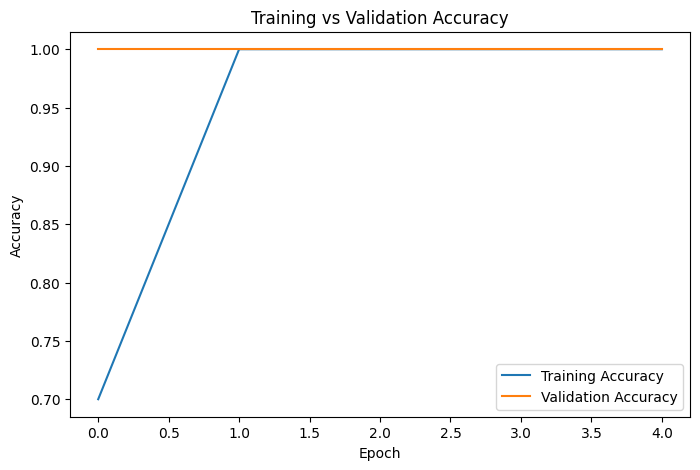

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

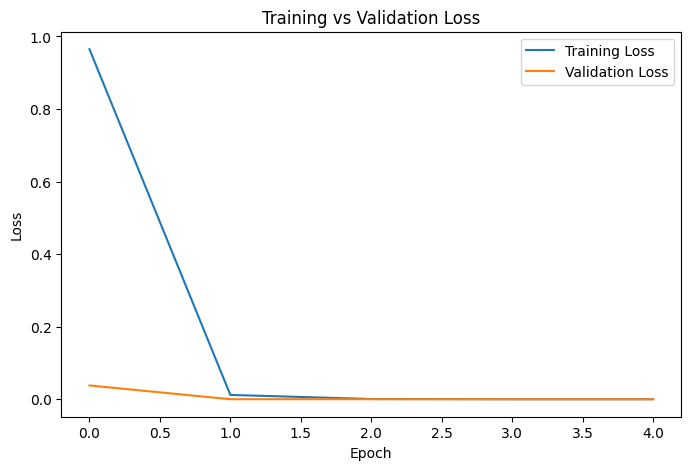

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

In [ ]:
val_loss, val_accuracy = model.evaluate(val_ds)

print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 1.0000 - loss: 1.3679e-06
Validation Loss: 0.0000
Validation Accuracy: 1.0000


In [ ]:
import os
import shutil
import random

test_dir = "/content/test_dataset"

test_class_a = os.path.join(test_dir, "Class_A")
test_class_b = os.path.join(test_dir, "Class_B")

os.makedirs(test_class_a, exist_ok=True)
os.makedirs(test_class_b, exist_ok=True)

random.seed(100)

# Get images
class_a_files = [
    os.path.join(class_a, f)
    for f in os.listdir(class_a)
    if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp"))
]

class_b_files = [
    os.path.join(class_b, f)
    for f in os.listdir(class_b)
    if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp"))
]

# Select 15 completely unseen images from each
test_a = random.sample(class_a_files, 15)
test_b = random.sample(class_b_files, 15)

for i, file in enumerate(test_a):
    ext = os.path.splitext(file)[1]
    shutil.copy2(file, os.path.join(test_class_a, f"test_a_{i}{ext}"))

for i, file in enumerate(test_b):
    ext = os.path.splitext(file)[1]
    shutil.copy2(file, os.path.join(test_class_b, f"test_b_{i}{ext}"))

print("Test Class A:", len(os.listdir(test_class_a)))
print("Test Class B:", len(os.listdir(test_class_b)))

Test Class A: 15
Test Class B: 15


In [ ]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=1,
    shuffle=False
)

print(test_ds.class_names)

Found 30 files belonging to 2 classes.
['Class_A', 'Class_B']


In [ ]:
test_loss, test_accuracy = model.evaluate(test_ds)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 2.5647e-06
Test Loss: 0.0000
Test Accuracy: 1.0000


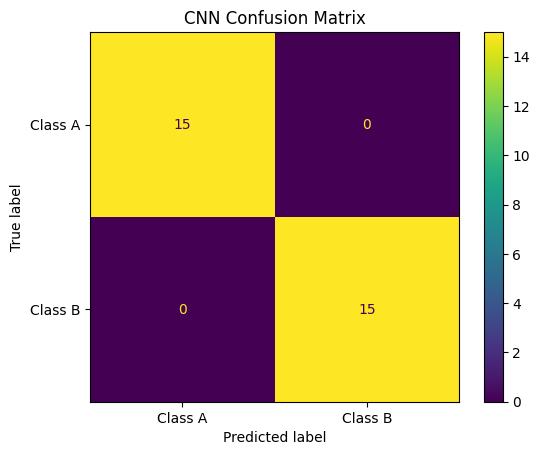

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_true = []
y_pred = []

for images, labels in test_ds:

    predictions = model.predict(images, verbose=0)

    predicted = (predictions > 0.5).astype(int).flatten()

    y_true.extend(labels.numpy())
    y_pred.extend(predicted)

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Class A", "Class B"]
)

disp.plot()

plt.title("CNN Confusion Matrix")
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=["Class A", "Class B"]
    )
)

              precision    recall  f1-score   support

     Class A       1.00      1.00      1.00        15
     Class B       1.00      1.00      1.00        15

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [ ]:
from google.colab import files

uploaded = files.upload()

Saving WhatsApp Image 2026-09-18 at 10.14.39 PM.jpeg to WhatsApp Image 2026-09-18 at 10.14.39 PM.jpeg


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import load_img, img_to_array

image_path = list(uploaded.keys())[0]

# Load and resize image
img = load_img(
    image_path,
    target_size=(180, 180)
)

# Convert image to array
img_array = img_to_array(img)

# Add batch dimension
img_array = np.expand_dims(img_array, axis=0)

# Predict
prediction = model.predict(img_array, verbose=0)[0][0]

print("Prediction value:", prediction)

if prediction < 0.5:
    print("Prediction: Class A")
else:
    print("Prediction: Class B")

Prediction value: 1.926991e-08
Prediction: Class A


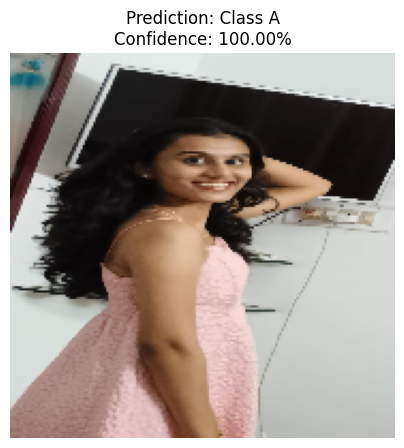

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 5))

plt.imshow(img)
plt.axis("off")

if prediction < 0.5:
    predicted_class = "Class A"
    confidence = (1 - prediction) * 100
else:
    predicted_class = "Class B"
    confidence = prediction * 100

plt.title(f"Prediction: {predicted_class}\nConfidence: {confidence:.2f}%")
plt.show()